In [1]:
!pip install numpy
!pip install torch
!pip install -q tqdm
!pip install matplotlib

In [17]:
import numpy as np
import torch
import torch.nn as nn
from tqdm import tqdm
from matplotlib import pyplot as plt

In [18]:
class SineLayer(nn.Module):
    def __init__(self, in_features, out_features, bias=True, is_first=False, omega_0=30.0):
        super().__init__()
        self.omega_0 = omega_0
        self.is_first = is_first
        self.in_features = in_features
        self.linear = nn.Linear(in_features, out_features, bias=bias)
        
        self.init_weights()
        
    def init_weights(self):
        with torch.no_grad():
            if self.is_first:
                # First layer needs a different scaling bound
                bound = 1 / self.in_features
                self.linear.weight.uniform_(-bound, bound)
            else:
                # Hidden layers are bound based on the inputs and omega_0
                bound = np.sqrt(6 / self.in_features) / self.omega_0
                self.linear.weight.uniform_(-bound, bound)
                
    def forward(self, x):
        return torch.sin(self.omega_0 * self.linear(x))

In [19]:
class SIREN(nn.Module):
    def __init__(self, in_features=2, hidden_features=256, hidden_layers=3, out_features=2, outermost_linear=True):
        super().__init__()
        
        self.net = []
        # First layer explicitly tagged as 'is_first=True'
        self.net.append(SineLayer(in_features, hidden_features, is_first=True, omega_0=30.0))

        # Hidden layers
        for _ in range(hidden_layers):
            self.net.append(SineLayer(hidden_features, hidden_features, is_first=False, omega_0=30.0))

        # Output layer (Usually linear if predicting raw physical values)
        if outermost_linear:
            final_linear = nn.Linear(hidden_features, out_features)
            with torch.no_grad():
                bound = np.sqrt(6 / hidden_features) / 30.0
                final_linear.weight.uniform_(-bound, bound)
            self.net.append(final_linear)
        else:
            self.net.append(SineLayer(hidden_features, out_features, is_first=False, omega_0=30.0))
            
        self.net = nn.Sequential(*self.net)
        
    def forward(self, x, t):
        # Ensure coordinates are cloned and tracked if computing derivatives for a PDE
        coords = torch.cat([x, t], dim=1)
        results = self.net(coords)
        return results[:, 0], results[:, 1]

In [20]:
def compute_schrodinger_equation_residue(model, x, t, m, hbar):
    psiR, psiI = model(x, t)

    psiR_t = torch.autograd.grad(psiR, t, torch.ones_like(psiR), create_graph=True, retain_graph=True)[0]
    psiI_t = torch.autograd.grad(psiI, t, torch.ones_like(psiI), create_graph=True, retain_graph=True)[0]

    psiR_x = torch.autograd.grad(psiR, x, torch.ones_like(psiR), create_graph=True, retain_graph=True)[0]
    psiR_xx = torch.autograd.grad(psiR_x, x, torch.ones_like(psiR_x), create_graph=True, retain_graph=True)[0]
    psiI_x = torch.autograd.grad(psiI, x, torch.ones_like(psiI), create_graph=True, retain_graph=True)[0]
    psiI_xx = torch.autograd.grad(psiI_x, x, torch.ones_like(psiI_x), create_graph=True, retain_graph=True)[0]

    residue_0 = -0.5*hbar*hbar/m * psiR_xx + hbar * psiI_t
    residue_1 = -0.5*hbar*hbar/m * psiI_xx - hbar * psiR_t
    return torch.square(residue_0).mean(), torch.square(residue_1).mean()

In [21]:
def analytical_solution(x, t, A, hbar, m, L):
    psi = A * np.sin(np.pi*x/L) * np.exp(-0.5*L*L*hbar/m*t*1.j)
    return np.real(psi), np.imag(psi)

In [22]:
device = torch.device("cuda")

In [23]:
n_colloc, n_bc = 5000, 200
epochs = 5000
hbar = 1.
m = 1.
L = 1.

In [24]:
x_colloc = torch.rand(n_colloc, 1, requires_grad=True).to(device)
t_colloc = torch.Tensor(4*np.pi*torch.rand(n_colloc, 1)).to(device)
t_colloc.requires_grad_()

# initial condition
x_ic = torch.rand(n_bc, 1).to(device)
t_ic = torch.zeros(n_bc, 1).to(device)
psiR_ic, psiI_ic = analytical_solution(x_ic.cpu().numpy(), t_ic.cpu().numpy(), 1., 1., 1., 1.)
psiR_ic = torch.FloatTensor(psiR_ic).to(device)
psiI_ic = torch.FloatTensor(psiI_ic).to(device)

# boundary conditions
x_bc = torch.cat([torch.zeros(n_bc // 2, 1), torch.ones(n_bc // 2, 1) * L]).to(device)
t_bc = torch.rand(n_bc, 1).to(device)
psiR_bc, psiI_bc = torch.zeros(n_bc, 1).to(device), torch.zeros(n_bc, 1).to(device)

In [25]:
pinn = SIREN().to(device)
optimizer = torch.optim.Adam(pinn.parameters(), lr=1e-3)

In [26]:
losses_pde_R = []
losses_pde_I = []
losses_ic_R = []
losses_ic_I = []
losses_bc_R = []
losses_bc_I = []
losses = []

In [27]:
for epoch in tqdm(range(epochs)):
    optimizer.zero_grad()

    loss_pde_R, loss_pde_I = compute_schrodinger_equation_residue(pinn, x_colloc, t_colloc, 1., 1.)
    pinn_ic_R, pinn_ic_I = pinn(x_ic, t_ic)
    loss_ic_R = nn.functional.mse_loss(pinn_ic_R.flatten()[:, None], psiR_ic)
    loss_ic_I = nn.functional.mse_loss(pinn_ic_I.flatten()[:, None], psiI_ic)
    pinn_bc_R, pinn_bc_I = pinn(x_bc, t_bc)
    loss_bc_R = nn.functional.mse_loss(pinn_bc_R.flatten()[:, None], psiR_bc)
    loss_bc_I = nn.functional.mse_loss(pinn_bc_I.flatten()[:, None], psiI_bc)

    loss = loss_pde_R + loss_pde_I + 10 * loss_ic_R + 10 * loss_ic_I + 10 * loss_bc_R + 10 * loss_bc_I

    loss.backward()
    optimizer.step()

    losses_pde_R.append(loss_pde_R.item())
    losses_pde_I.append(loss_pde_I.item())
    losses_ic_R.append(loss_ic_R.item())
    losses_ic_I.append(loss_ic_I.item())
    losses_bc_R.append(loss_bc_R.item())
    losses_bc_I.append(loss_bc_I.item())
    losses.append(loss.item())

    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch}: {loss.item():.2f}")

 11%|█         | 527/5000 [00:03<00:27, 159.80it/s]

Epoch 499: 2.80


 20%|██        | 1023/5000 [00:06<00:25, 157.76it/s]

Epoch 999: 2.79


 30%|███       | 1519/5000 [00:09<00:22, 157.93it/s]

...

Epoch 3999: 165836439552.00


 91%|█████████ | 4527/5000 [00:28<00:02, 158.13it/s]

Epoch 4499: 422.55


100%|██████████| 5000/5000 [00:31<00:00, 158.78it/s]

Epoch 4999: 2.79


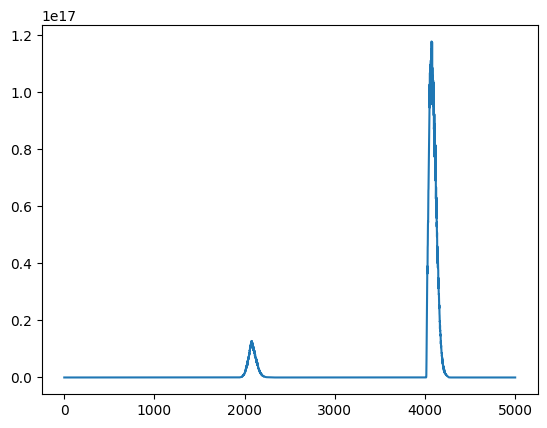

In [28]:
plt.plot(range(epochs), losses)

In [29]:
with torch.no_grad():
    x_test = torch.linspace(0., 1., 100).flatten()[:, None].to(device)
    psi = pinn(x_test, 0.1*torch.ones(100).flatten()[:, None].to(device))

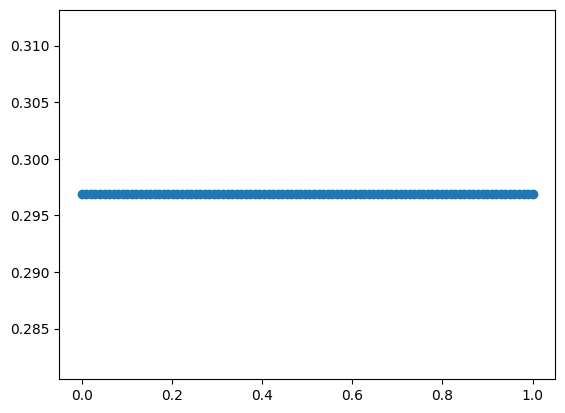

In [30]:
plt.scatter(x_test.cpu().numpy(), psi[0].cpu().numpy())

In [31]:
with torch.no_grad():
    t_test = torch.linspace(0, 4*torch.pi, 100).to(device).flatten()[:, None]
    x_test = torch.ones(100).to(device).flatten()[:, None] * 0.5
    psi = pinn(x_test, t_test)

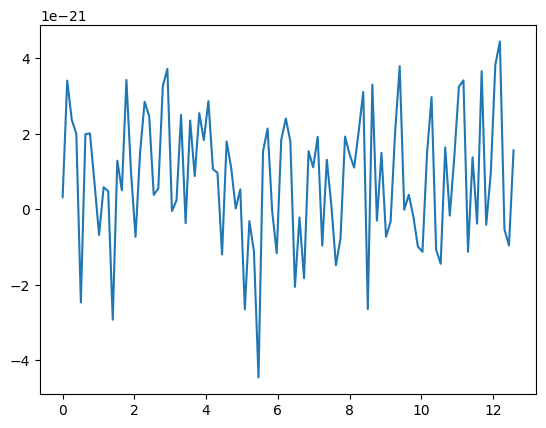

In [32]:
plt.plot(t_test.cpu().numpy(), psi[1].cpu().numpy())